In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from tslearn.metrics import cdist_dtw
from helper_plots import plot_pseudotime_for_cells
from pathlib import Path

def sample_rows_per_cluster(df, cluster_col, n=5, random_state=42):
    return (
        df
        .groupby(cluster_col, group_keys=False)
        .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))
    )


def compute_mean_std(ts_list):
    ts_list = [np.asarray(ts, dtype=float) for ts in ts_list]
    max_len = max(len(ts) for ts in ts_list)
    aligned = [
        np.pad(ts, (0, max_len - len(ts)), constant_values=np.nan)
        for ts in ts_list
    ]
    mat = np.vstack(aligned)
    return np.nanmean(mat, axis=0), np.nanstd(mat, axis=0)

def plot_kmeans_mean_shapes(X, labels):
    plt.figure(figsize=(12,6))

    for lab in sorted(set(labels)):
        idx = np.where(labels == lab)[0]
        ts_list = [X[i] for i in idx]

        mean_ts, std_ts = compute_mean_std(ts_list)
        t = np.arange(len(mean_ts))

        plt.plot(t, mean_ts, label=f"Cluster {lab}", linewidth=2)
        plt.fill_between(t, mean_ts - std_ts, mean_ts + std_ts, alpha=0.2)

    plt.title("KMeans Mean Shape per Cluster (± STD)")
    plt.legend()
    plt.show()

In [32]:

SD_clean = pd.read_pickle("checkpoints/pseudotime_cells_clean_1462.pkl")

n = 6  # minimum required length

SD_clean = SD_clean[SD_clean["pseudotime_widths"].apply(len) >= n]


outliers = []
with open(r"datasets\1462_dapi_python_segmentation_outliers.txt", "r") as f:
    for line in f:
        outliers.append(line.strip() +".tif")

print(outliers)

SD_clean = SD_clean[
    ~SD_clean["path_dapi"].apply(lambda p: Path(p).name).isin(outliers)
]


#X = SD_clean["pseudotime_widths"].to_list()

SD_clean

['obj6020001_stainDAPI.tif', 'obj6130001_stainDAPI.tif', 'obj6130004_stainDAPI.tif', 'obj6360001_stainDAPI.tif', 'obj6460002_stainDAPI.tif', 'obj6470001_stainDAPI.tif', 'obj6640001_stainDAPI.tif', 'obj6640002_stainDAPI.tif', 'obj6760002_stainDAPI.tif', 'obj7000001_stainDAPI.tif', 'obj2690001_stainDAPI.tif', 'obj2840001_stainDAPI.tif', 'obj2990015_stainDAPI.tif', 'obj2990024_stainDAPI.tif', 'obj2990036_stainDAPI.tif', 'obj2990041_stainDAPI.tif', 'obj3370001_stainDAPI.tif', 'obj3370002_stainDAPI.tif', 'obj3370003_stainDAPI.tif', 'obj4570003_stainDAPI.tif', 'obj4650001_stainDAPI.tif', 'obj4700002_stainDAPI.tif', 'obj4750001_stainDAPI.tif', 'obj4920001_stainDAPI.tif', 'obj4970001_stainDAPI.tif', 'obj4980001_stainDAPI.tif', 'obj4980002_stainDAPI.tif', 'obj5210002_stainDAPI.tif', 'obj5210003_stainDAPI.tif', 'obj5420001_stainDAPI.tif', 'obj130002_stainDAPI.tif', 'obj220001_stainDAPI.tif', 'obj1370002_stainDAPI.tif', 'obj2010001_stainDAPI.tif', 'obj2500001_stainDAPI.tif', 'obj49800010002_stain

,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,centered_bbox_min_y,centered_bbox_max_x,centered_bbox_max_y,bbox_rot_min_x,bbox_rot_min_y,bbox_rot_max_x,bbox_rot_max_y,pseudotime,pseudotime_widths,pseudotime_center_bin
obj_id,,,,,,,,,,,,,,,,,,,,,
10001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.320611,8.603053,0.293314,...,-47.5,-7.5,-28.5,-54.673717,-38.246672,-20.130126,-7.757514,"[10, 11, 12, 13, 14, 15, 16, 0, 1, 2, 3, 4, 5,...","[10, 9, 8, 6, 9, 16, 28, 30, 19, 14, 11, 10, 9...",1
20001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.272553,5.027085,0.366094,...,-44.5,-19.5,-28.5,-50.609170,-29.909800,-30.691879,-9.181622,"[12, 13, 14, 15, 16, 0, 1, 2, 3, 4, 5]","[8, 6, 9, 16, 28, 30, 19, 14, 11, 10, 9]",16
30001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.171021,5.244656,0.419590,...,43.5,-29.5,74.5,-23.797810,52.290090,9.401045,89.543380,"[8, 9, 10, 11, 12, 13, 14, 15, 16, 0, 1, 2, 3,...","[10, 10, 10, 9, 9, 6, 9, 16, 28, 30, 19, 14, 1...",0
40001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.165913,4.848332,0.433454,...,62.5,-25.5,81.5,-13.018165,67.114056,16.244550,94.754997,"[13, 14, 15, 16, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9,...","[6, 9, 16, 28, 30, 19, 14, 13, 10, 9, 9, 9, 9,...",3
50001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.519174,12.748607,0.539141,...,-11.5,52.5,4.5,22.265522,-35.043577,48.343836,-10.992480,"[14, 15, 16, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[9, 16, 29, 30, 17, 13, 11, 10, 8, 8, 8, 10, 1...",3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7240001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.306034,11.760468,0.419473,...,-1.5,8.5,17.5,-19.635197,-5.355193,15.788541,25.608668,"[10, 11, 12, 13, 14, 15, 16, 0, 1, 2, 3, 4, 5,...","[9, 9, 8, 8, 9, 14, 27, 30, 18, 14, 12, 10, 9,...",1
7250001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.031863,0.800109,0.474371,...,-6.5,-8.5,9.5,-30.810172,-1.685976,-2.971566,23.314526,"[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 0,...","[9, 8, 9, 9, 10, 9, 9, 8, 8, 9, 14, 27, 30, 18...",11
7260001,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.064615,1.787692,0.812035,...,-17.5,46.5,5.5,9.735698,-37.476237,43.537662,-4.890603,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 0, 1, 2,...","[9, 10, 10, 10, 9, 8, 8, 9, 16, 29, 30, 17, 13...",16


In [33]:
df_identifyPrimaryObjects = pd.read_csv("datasets/1462/MyExpt_IdentifyPrimaryObjects.csv")
df_Phalloidin_segmented = pd.read_csv("datasets/1462/MyExpt_Phalloidin_segmented.csv")
df_YAP_segmented = pd.read_csv("datasets/1462/MyExpt_YAP_segmented.csv")

SD_clean["ImageNumber"] = SD_clean.index // 10000
SD_clean["ObjectNumber"] = SD_clean.index % 10000

keys = ["Metadata_ObjNumber", "ObjectNumber"]

cluster_map = SD_clean.rename(columns={"ImageNumber": "Metadata_ObjNumber"})

def prepare_df(df, prefix, keys):
    # rename all non-key columns with a prefix
    rename_dict = {
        col: f"{prefix}_{col}"
        for col in df.columns
        if col not in keys
    }
    return df.rename(columns=rename_dict)

# prefix each dataframe to avoid collisions
df_id = prepare_df(df_identifyPrimaryObjects, "dapi", keys)
df_ph = prepare_df(df_Phalloidin_segmented, "phalloidin", keys)
df_yap = prepare_df(df_YAP_segmented, "yap", keys)

# merge everything into one dataframe
SD_clean = (
    cluster_map
    .merge(df_id, on=keys, how="inner")
    .merge(df_ph, on=keys, how="inner")
    .merge(df_yap, on=keys, how="inner")
)

X = SD_clean["pseudotime_widths"].to_list()

SD_clean

,path_background,path_dapi,path_yap,path_actin,height,width,channels,radial_distribution.RadialDistribution_FracAtD_1of4,radial_distribution.RadialDistribution_MeanFrac_1of4,radial_distribution.RadialDistribution_RadialCV_1of4,...,yap_Texture_Variance_DNA_3_02_256,yap_Texture_Variance_DNA_3_03_256,yap_Texture_Variance_Phalloidin_3_00_256,yap_Texture_Variance_Phalloidin_3_01_256,yap_Texture_Variance_Phalloidin_3_02_256,yap_Texture_Variance_Phalloidin_3_03_256,yap_Texture_Variance_YAP_3_00_256,yap_Texture_Variance_YAP_3_01_256,yap_Texture_Variance_YAP_3_02_256,yap_Texture_Variance_YAP_3_03_256
0,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.272553,5.027085,0.366094,...,997.610630,1126.502386,171.749395,179.184018,176.648019,184.907450,80.501909,81.894739,81.730408,86.665047
1,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.291339,11.313648,0.074859,...,333.682094,307.274632,223.648385,236.215302,226.674144,237.144743,61.703252,62.295044,63.721991,67.622438
2,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.091195,3.217880,0.099620,...,1281.410406,1243.886943,17.479380,17.211286,17.092793,17.782992,38.533308,39.719367,40.900411,42.628598
3,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.596045,15.099812,0.071041,...,324.427362,350.301213,100.106435,98.733507,100.935057,103.472602,50.289696,51.613114,51.159827,53.794477
4,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.084586,3.397556,0.359751,...,681.679039,748.972642,327.802406,332.799489,344.398282,366.057958,99.556157,100.588209,104.903413,114.351756
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.085417,2.101250,0.306219,...,1692.760995,1876.592389,106.071809,105.968158,106.698316,105.442851,31.716749,32.296666,32.194359,33.885867
410,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.232836,6.364179,0.457974,...,2607.273115,2894.976846,672.385758,683.576104,710.110683,641.624949,106.213995,106.258756,111.292402,125.204413
411,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.166102,4.983051,0.358465,...,344.276903,356.737354,178.339263,172.673467,179.778028,181.339325,54.980463,55.683000,55.376667,56.572495
412,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,C:\Users\20212358\OneDrive - TU Eindhoven\pseu...,300,300,"actin,background,dapi,yap",0.031863,0.800109,0.474371,...,1587.326605,1735.945532,2

In [34]:
from sklearn.cluster import KMeans


features = [
    [
        np.mean(ts),
        np.std(ts),
        # np.max(ts),
        # np.min(ts),
        len(ts)
    ]
    for ts in X
]

# #ignore class 3(grenn)
kmeans = KMeans(n_clusters=6, random_state=42)
# kmeans.fit(features)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=3)
X_embedded = pca.fit_transform(X_scaled)

kmeans.fit(X_embedded)


,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


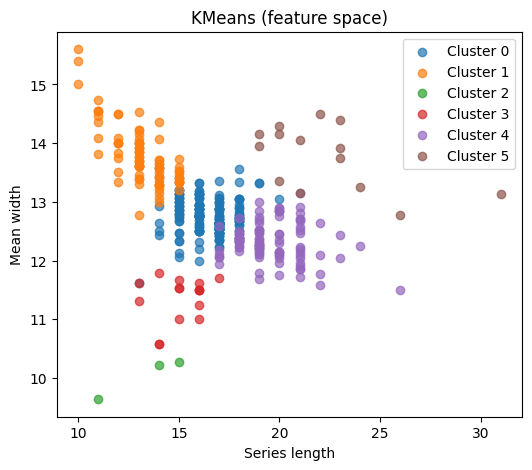

In [35]:
labels_kmeans = kmeans.labels_

features = np.array(features)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(
        features[idx, -1],     # length
        features[idx, 0],      # mean
        label=f"Cluster {c}",
        alpha=0.7
    )

plt.xlabel("Series length")
plt.ylabel("Mean width")
plt.title("KMeans (feature space)")
plt.legend()
plt.show()

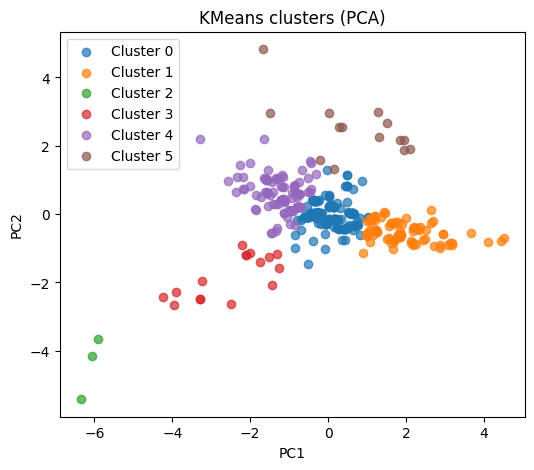

In [36]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(features)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for c in np.unique(labels_kmeans):
    idx = labels_kmeans == c
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters (PCA)")
plt.legend()
plt.show()

C:\Users\20212358\AppData\Local\Temp\ipykernel_23184\1429122847.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(n, len(x)), random_state=random_state))


C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj3210001_stainDAPI.tif
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj2650001_stainDAPI.tif
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj5910001_stainDAPI.tif
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj5800001_stainDAPI.tif
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj2850001_stainDAPI.tif


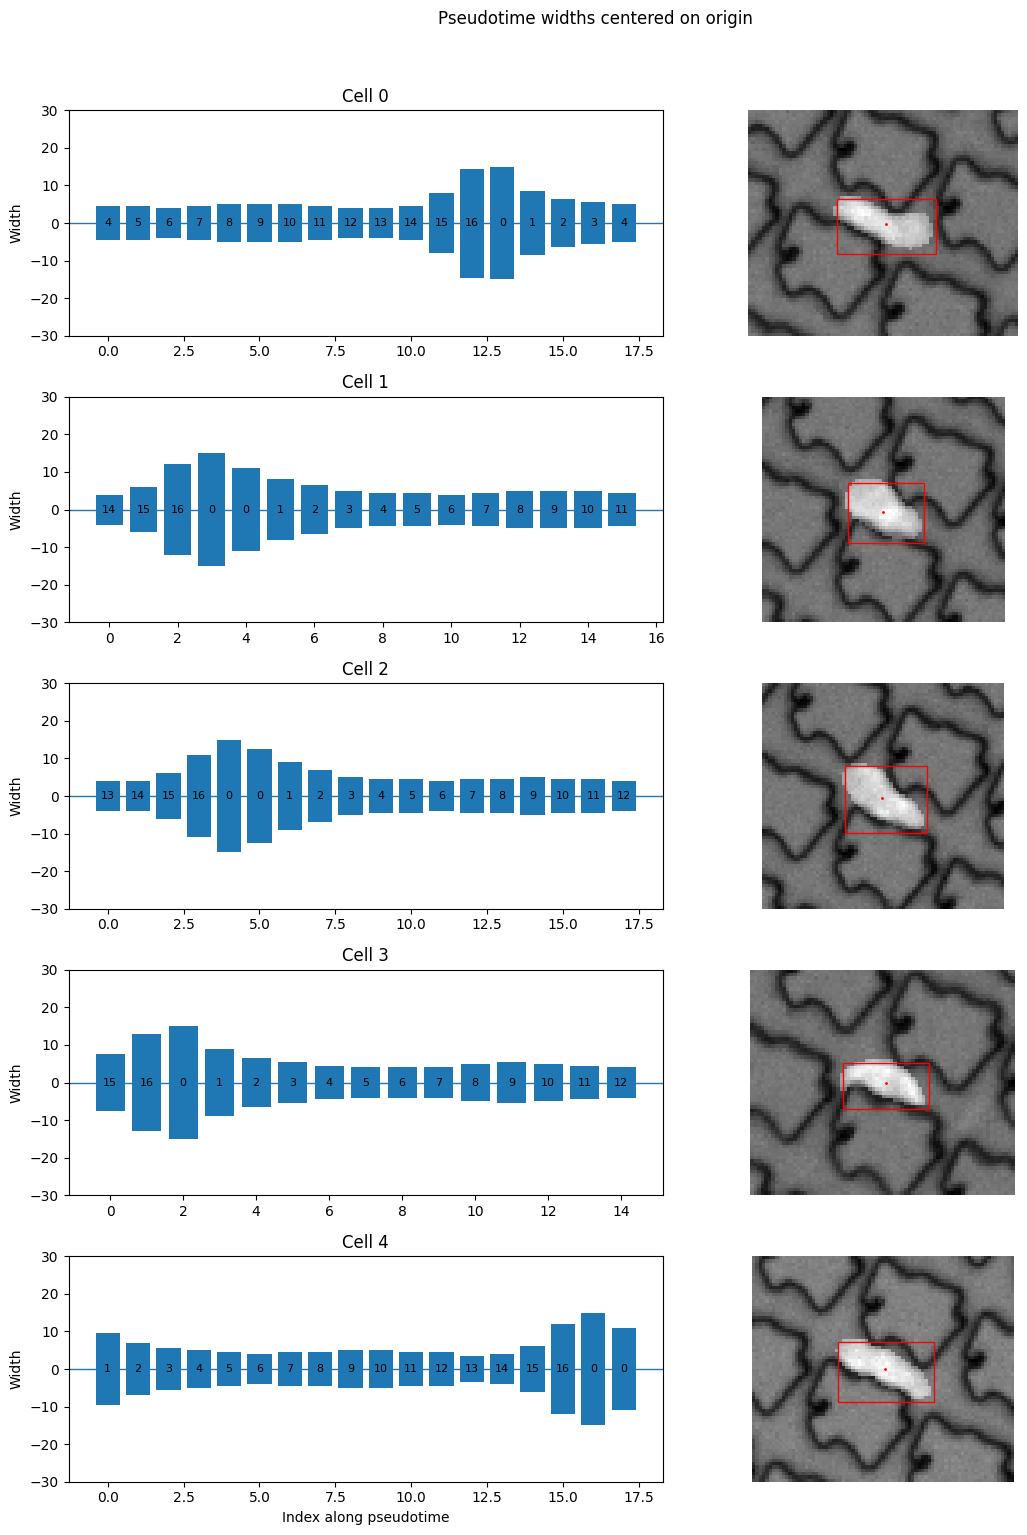

C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj20001_stainDAPI.tif
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj1480001_stainDAPI.tif
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj2910001_stainDAPI.tif
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj6420001_stainDAPI.tif
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj2610002_stainDAPI.tif


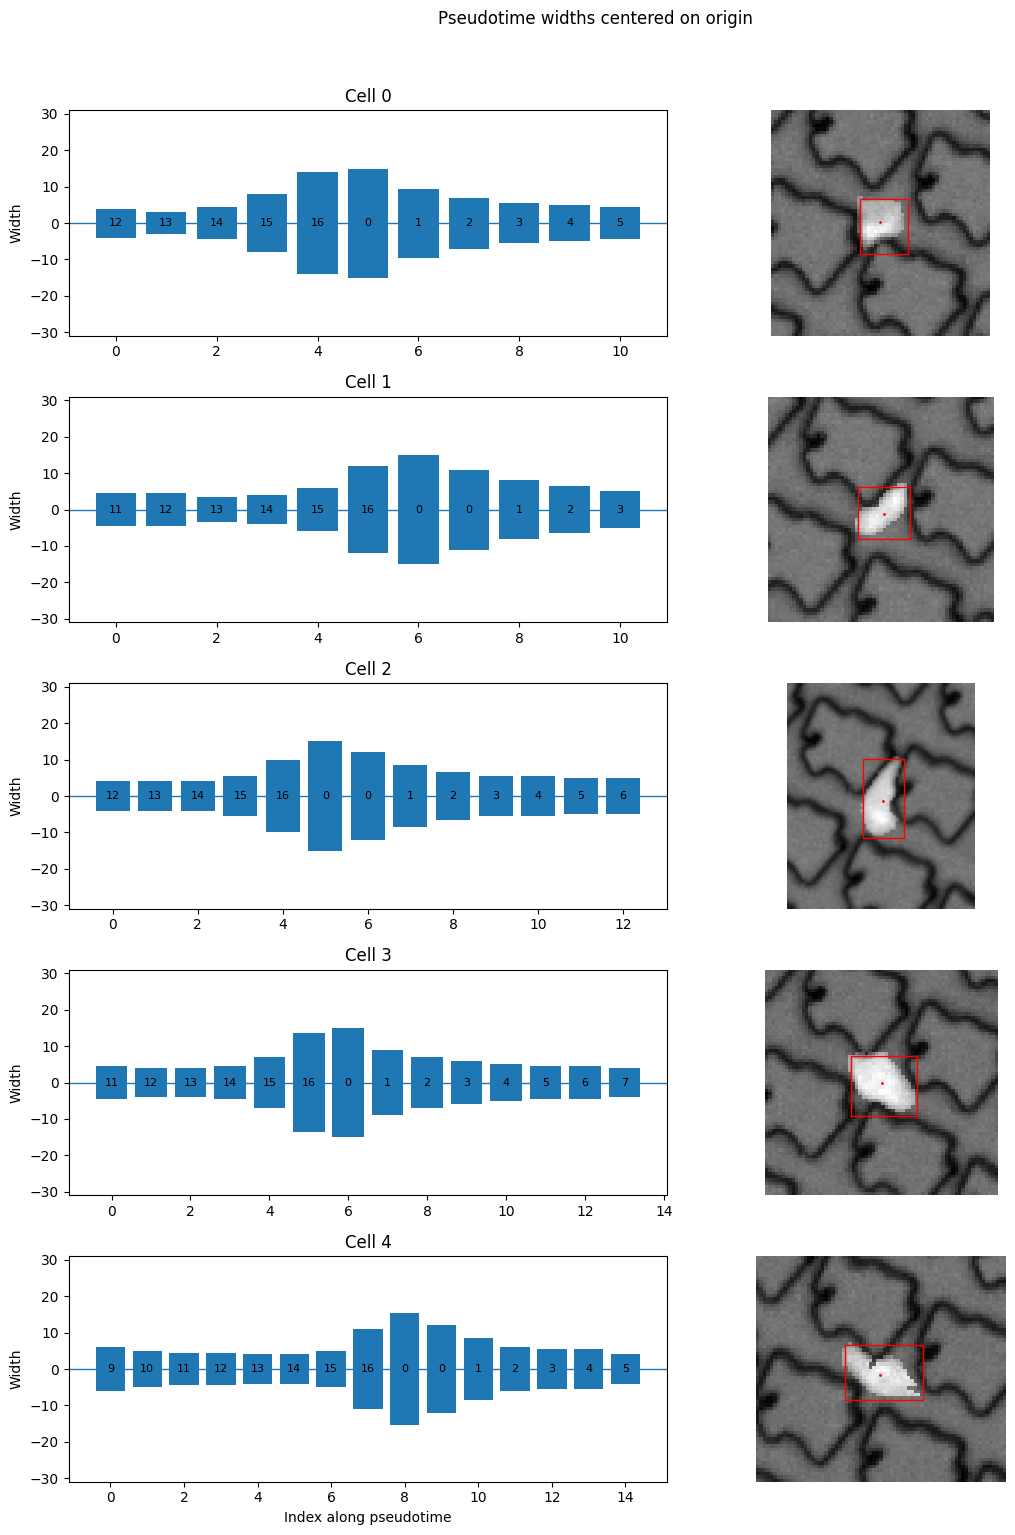

C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj160001_stainDAPI.tif
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj1340001_stainDAPI.tif
C:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\Chip_1462_1_real\separated dapi\obj5400001_stainDAPI.tif


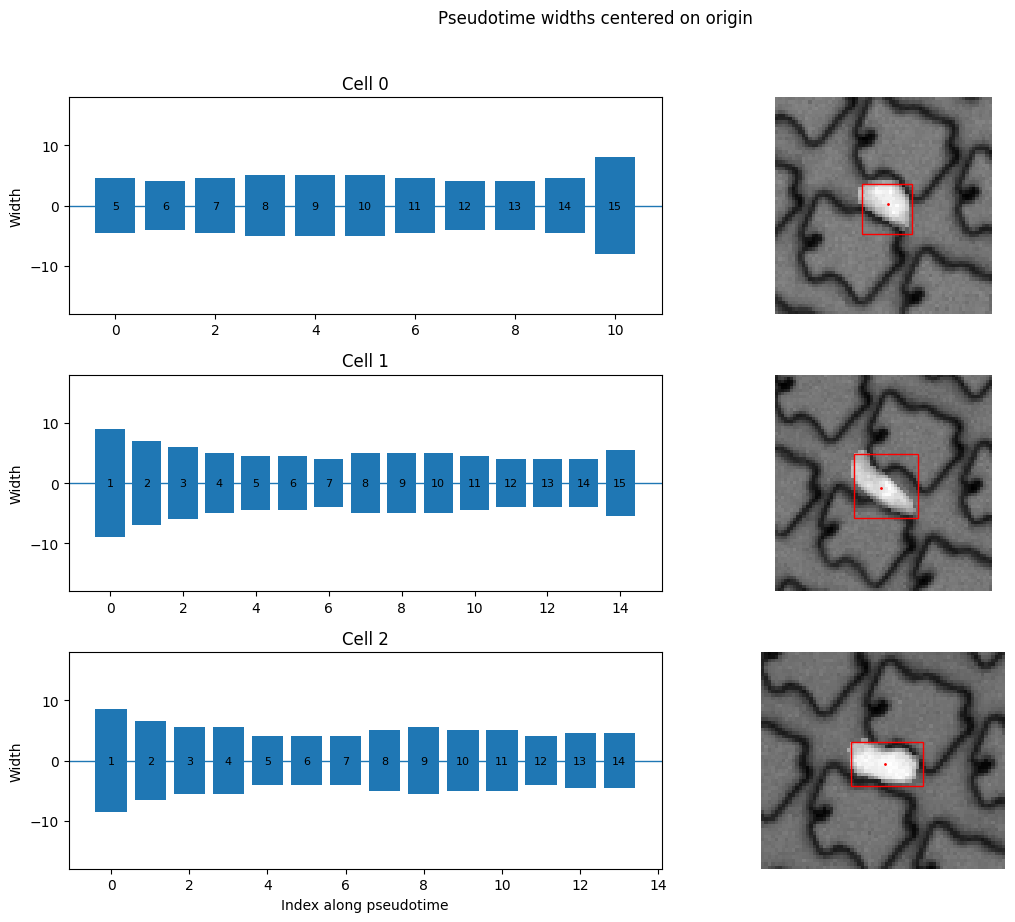

In [37]:
SD_clean['cluster_kmeans'] = labels_kmeans

df_kmeans_samples = sample_rows_per_cluster(
    SD_clean,
    cluster_col='cluster_kmeans',
    n=5
)

df_kmeans_samples

plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 0'), num_cells=5)
plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 1'), num_cells=5)
plot_pseudotime_for_cells(df_kmeans_samples.query('cluster_kmeans == 2'), num_cells=5)

<Axes: xlabel='cluster_kmeans'>

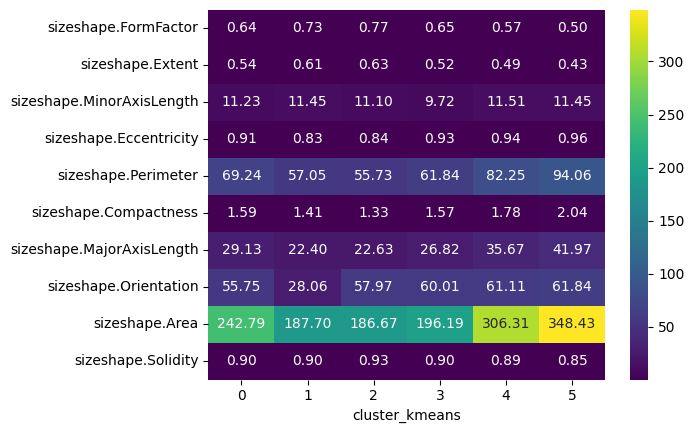

In [38]:
import seaborn as sns

feats = ['AreaShape_FormFactor', 'AreaShape_Extent','AreaShape_MinorAxisLength',
         'AreaShape_Eccentricity',  'AreaShape_Perimeter', 'AreaShape_Compactness', 
         'AreaShape_MajorAxisLength', 'AreaShape_Orientation',
         'AreaShape_Area','AreaShape_Solidity',
        ]

def name_in_df(feat):
    return  'sizeshape.' + feat.split('_')[1]

feats_CPmeasure = []
for feat in feats:
    col = name_in_df(feat)
    if col in SD_clean.columns:
        feats_CPmeasure.append(col)
    else:
        print(f"Feature {name_in_df(feat)} not found in dataframe")


SD_clean[feats_CPmeasure + ['cluster_kmeans']].groupby('cluster_kmeans').mean()

sns.heatmap( SD_clean[feats_CPmeasure + ['cluster_kmeans']] .groupby('cluster_kmeans') .mean() .T, cmap="viridis", annot=True, fmt=".2f" )

<Axes: xlabel='cluster_kmeans'>

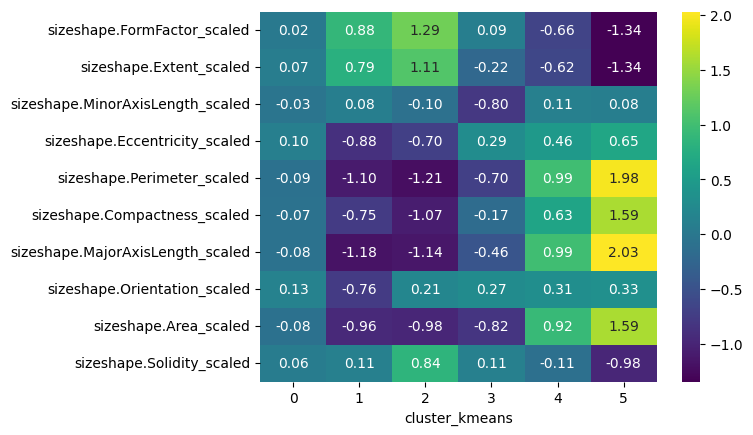

In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled = scaler.fit_transform(SD_clean[feats_CPmeasure])

feats_CPmeasure_scaled = [f + "_scaled" for f in feats_CPmeasure]

SD_clean[feats_CPmeasure_scaled] = scaled



sns.heatmap(
    SD_clean[feats_CPmeasure_scaled + ['cluster_kmeans']]
    .groupby('cluster_kmeans')
    .mean()
    .T,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

0 0.4465657548615143
1 0.42899827935315604
2 0.7388188097729514
3 0.32865170009364375
4 0.3575427911690022
5 0.2790278039409301


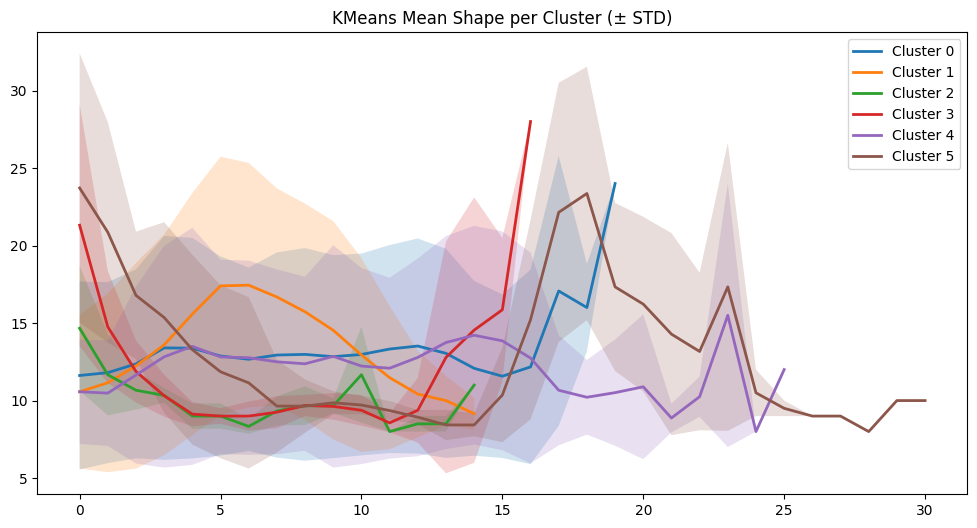

In [40]:
from sklearn.metrics import silhouette_samples

s = silhouette_samples(X_scaled, labels_kmeans)
for k in np.unique(labels_kmeans):
    print(k, s[labels_kmeans == k].mean())

X_kmeans = SD_clean["pseudotime_widths"].to_list()
labels_kmeans = SD_clean["cluster_kmeans"].values

plot_kmeans_mean_shapes(X_kmeans, labels_kmeans)  

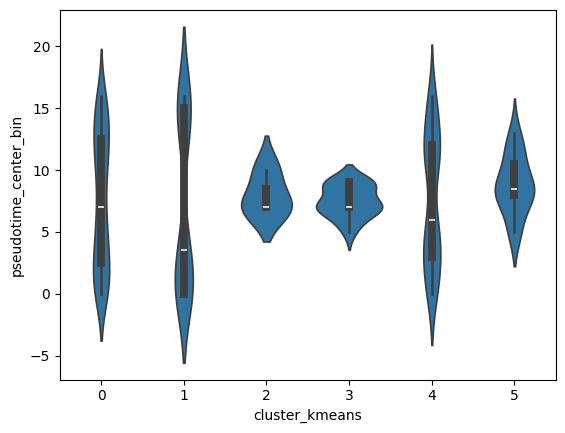

In [41]:
sns.violinplot(x='cluster_kmeans', y='pseudotime_center_bin', data=SD_clean)
plt.show()

In [42]:
mask = labels_kmeans != 2
features_no_outliers = features[mask]
X_scaled_no_Outliers = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=2, random_state=42)
labels_clean = kmeans.fit_predict(X_scaled_no_Outliers)
    
s_clean = silhouette_samples(X_scaled_no_Outliers, labels_clean)

for k in np.unique(labels_clean):
    print(k, s_clean[labels_clean == k].mean())


0 0.39631983825624645
1 0.42693393195978485


<Axes: xlabel='cluster_kmeans_no_outliers'>

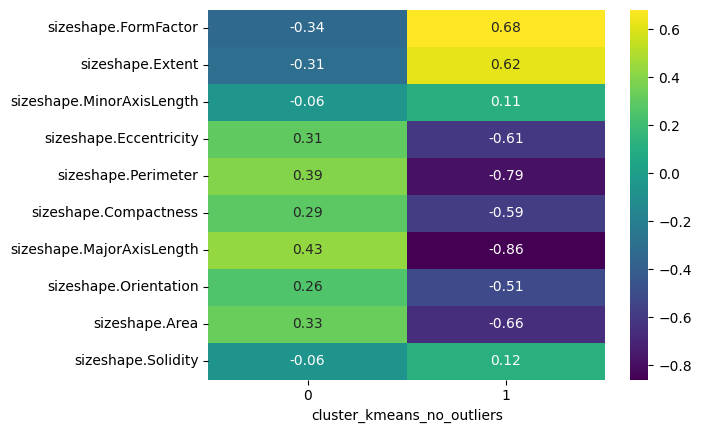

In [43]:
SD_clean_no_outliers = SD_clean.copy()
SD_clean_no_outliers['cluster_kmeans_no_outliers'] = np.where(mask, labels_clean, -1)
SD_clean_no_outliers = SD_clean_no_outliers[SD_clean_no_outliers['cluster_kmeans_no_outliers'] != -1]

scaler = StandardScaler()
scaled = scaler.fit_transform(SD_clean_no_outliers[feats_CPmeasure])

SD_clean_no_outliers[feats_CPmeasure] = scaled

sns.heatmap(
    SD_clean_no_outliers[feats_CPmeasure + ['cluster_kmeans_no_outliers']]
    .groupby('cluster_kmeans_no_outliers')
    .mean()
    .T,
    cmap="viridis",
    annot=True,
    fmt=".2f"
)

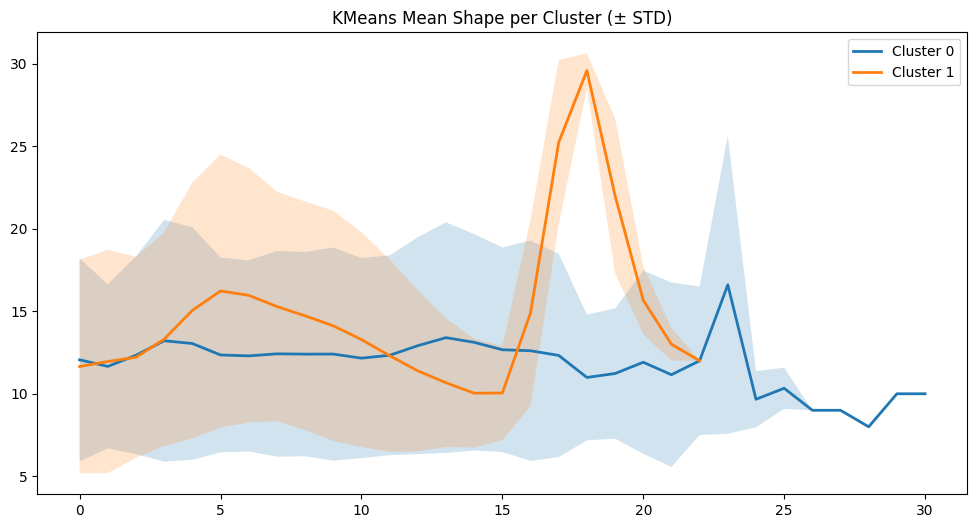

In [44]:
X_kmeans = SD_clean_no_outliers["pseudotime_widths"].to_list()
labels_kmeans = SD_clean_no_outliers["cluster_kmeans_no_outliers"].values



plot_kmeans_mean_shapes(X_kmeans, labels_kmeans)

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# 1) Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# 2) Optional: PCA to remove collinearity/noise
pca = PCA(n_components=2)  # or more components if needed
X_pca = pca.fit_transform(X_scaled)

# 3) Fit GMM
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
gmm.fit(X_pca)

# 4) Cluster labels (hard assignment)
labels_gmm = gmm.predict(X_pca)

# 5) Membership probabilities (soft assignment)
probs = gmm.predict_proba(X_pca)   # shape: (n_samples, 3)

# 6) Evaluate quality
sil = silhouette_score(X_pca, labels_gmm)
print("Silhouette GMM:", sil)

Silhouette GMM: 0.3502657695319563


In [46]:
import hdbscan

X = SD_clean['pseudotime_widths'].to_list()

X = [ts for ts in X if len(ts) >= n]  # filter out short series

X = [(ts - np.mean(ts)) / np.std(ts) for ts in X] # z-score normalization

D_dtw = cdist_dtw(X)


In [47]:
import umap
lengths = np.array([len(ts) for ts in X])
L = np.abs(lengths[:, None] - lengths[None, :])

alpha = 0.3  # controls importance of length
D = D_dtw + alpha * L

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric='euclidean'
)

mapper = umap.UMAP(
    metric="precomputed",
    n_neighbors=15,
    min_dist=0.025,
    random_state=42
)

X_umap = mapper.fit_transform(D_dtw)

labels_hdb = clusterer.fit_predict(X_umap)  # -1 = noise

unique, counts = np.unique(labels_hdb, return_counts=True)
print(dict(zip(unique, counts)))

c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\.venv\lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\20212358\OneDrive - TU Eindhoven\pseudotime_GitHUB\pseudotime\.venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{np.int64(-1): np.int64(10), np.int64(0): np.int64(29), np.int64(1): np.int64(248), np.int64(2): np.int64(127)}


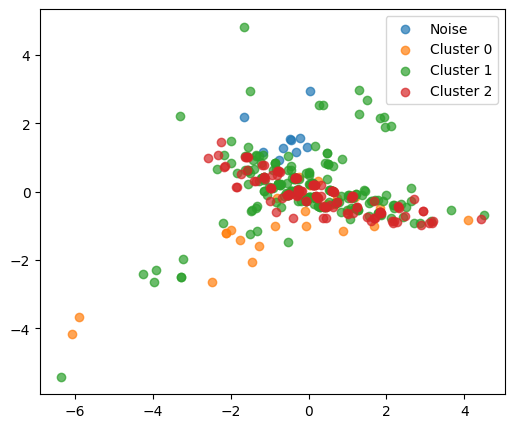

In [48]:
plt.figure(figsize=(6,5))
for c in np.unique(labels_hdb):
    idx = labels_hdb == c
    label = "Noise" if c == -1 else f"Cluster {c}"
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.7)
plt.legend()
plt.show()

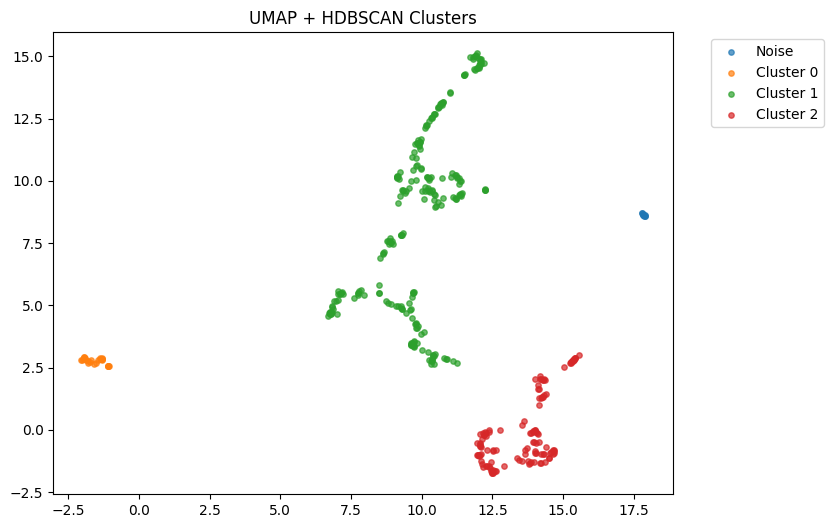

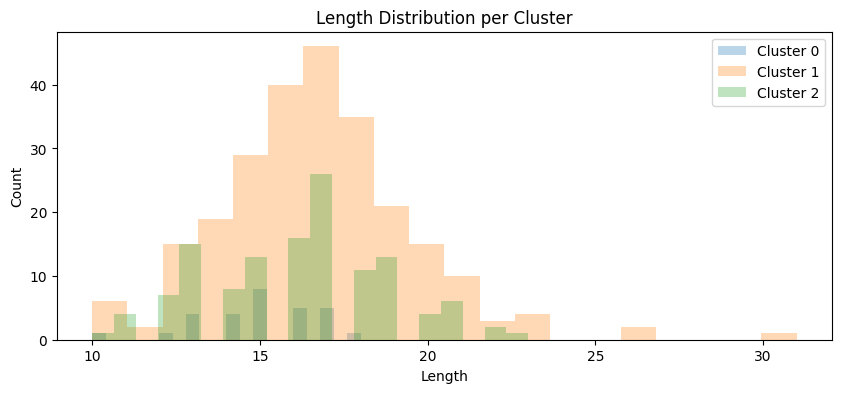

In [49]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))
unique_labels = np.unique(labels_hdb)

for lab in unique_labels:
    idx = labels_hdb == lab
    label = "Noise" if lab == -1 else f"Cluster {lab}"
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], s=15, alpha=0.7, label=label)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("UMAP + HDBSCAN Clusters")
plt.show()

def plot_length_distribution(X, labels):
    lengths = np.array([len(ts) for ts in X])

    plt.figure(figsize=(10,4))
    for lab in sorted(set(labels)):
        if lab == -1:
            continue
        idx = labels == lab
        plt.hist(lengths[idx], bins=20, alpha=0.3, label=f"Cluster {lab}")

    plt.legend()
    plt.title("Length Distribution per Cluster")
    plt.xlabel("Length")
    plt.ylabel("Count")
    plt.show()

plot_length_distribution(X, labels_hdb)

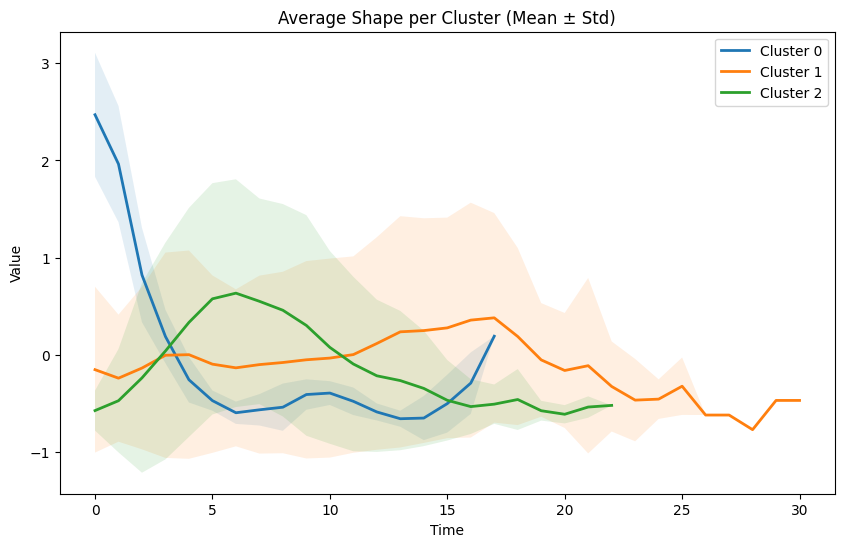

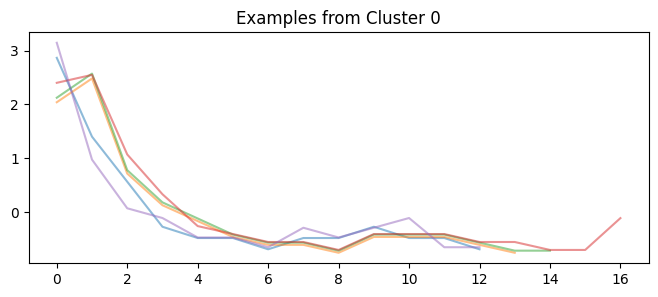

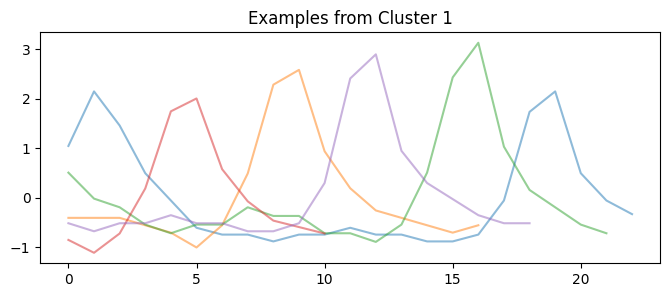

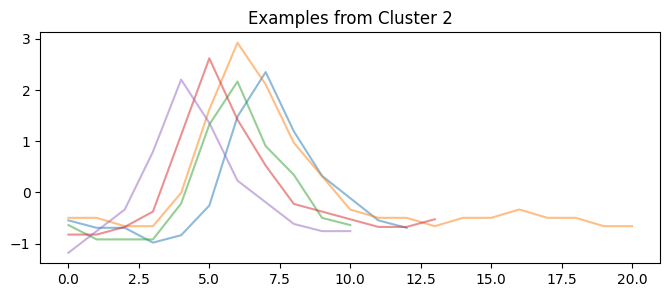

In [50]:
plt.figure(figsize=(10, 6))

for lab in np.unique(labels_hdb):
    if lab == -1:
        continue

    idx = labels_hdb == lab
    cluster_ts = [np.asarray(X[i], dtype=float) for i in np.where(idx)[0]]

    # Pad all sequences to the max length
    max_len = max(len(ts) for ts in cluster_ts)
    aligned = [
        np.pad(ts, (0, max_len - len(ts)), 'constant', constant_values=np.nan)
        for ts in cluster_ts
    ]
    aligned = np.vstack(aligned)

    # Mean and STD
    mean_ts = np.nanmean(aligned, axis=0)
    std_ts  = np.nanstd(aligned, axis=0)

    t = np.arange(max_len)

    # Plot mean
    plt.plot(t, mean_ts, label=f"Cluster {lab}", linewidth=2)

    # Plot STD as shaded area
    plt.fill_between(t, mean_ts - std_ts, mean_ts + std_ts, alpha=0.12)

plt.legend()
plt.title("Average Shape per Cluster (Mean ± Std)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

import random

for lab in np.unique(labels_hdb):
    if lab == -1:
        continue
    
    idx = np.where(labels_hdb == lab)[0]
    sample_idxs = random.sample(list(idx), min(5, len(idx)))

    plt.figure(figsize=(8, 3))
    for i in sample_idxs:
        plt.plot(X[i], alpha=0.5)
    plt.title(f"Examples from Cluster {lab}")
    plt.show()

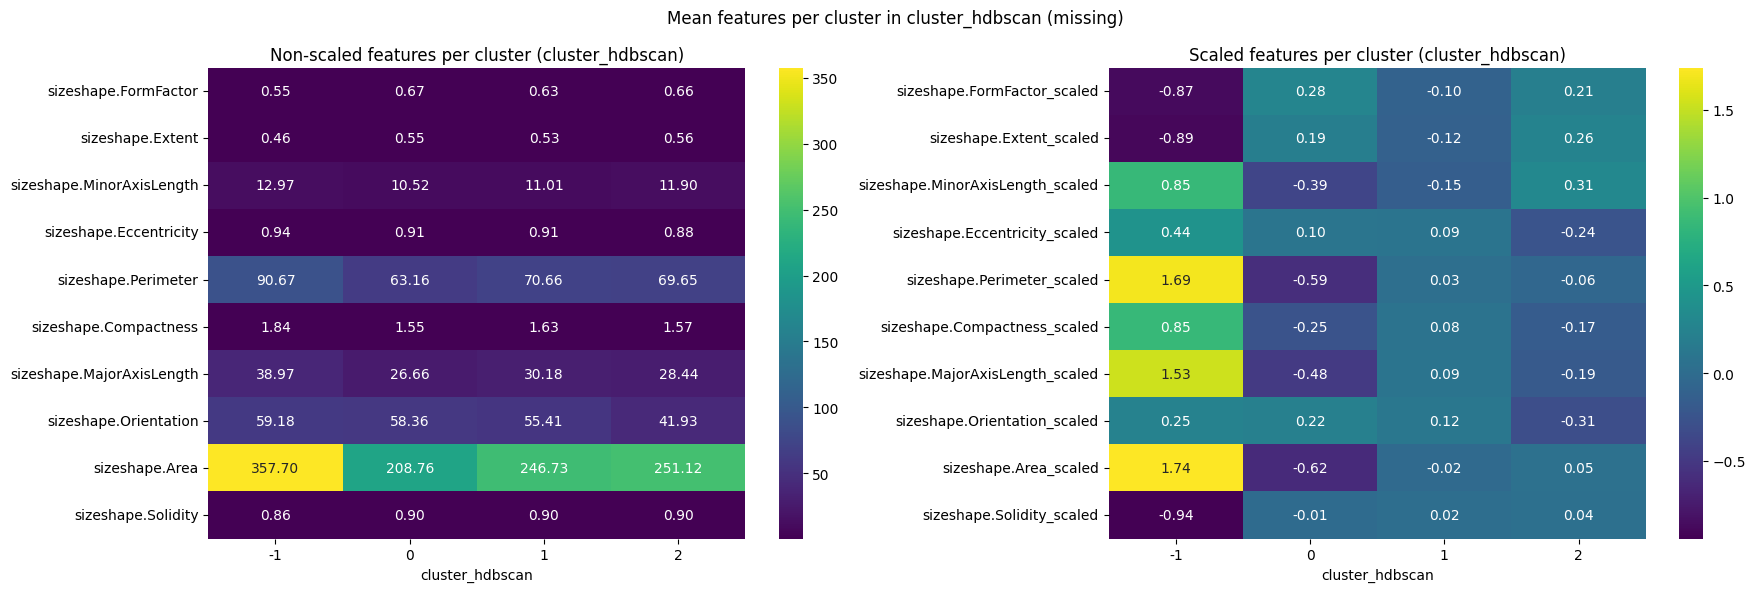

In [51]:
SD_clean["cluster_hdbscan"] = labels_hdb

def plot_metadata_heatmap(
    df,
    scaled_features,
    non_scaled_features,
    cluster_col,
    title="missing"
):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

    # --- Non-scaled features heatmap ---
    non_scaled_data = (
        df[non_scaled_features + [cluster_col]]
        .groupby(cluster_col)
        .mean()
        .T
    )

    sns.heatmap(
        non_scaled_data,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=axes[0]
    )

    axes[0].set_title(f"Non-scaled features per cluster ({cluster_col})")

    # --- Scaled features heatmap ---
    scaled_data = (
        df[scaled_features + [cluster_col]]
        .groupby(cluster_col)
        .mean()
        .T
    )

    sns.heatmap(
        scaled_data,
        cmap="viridis",
        annot=True,
        fmt=".2f",
        ax=axes[1]
    )

    axes[1].set_title(f"Scaled features per cluster ({cluster_col})")

    fig.suptitle(f"Mean features per cluster in {cluster_col} ({title})")

    plt.tight_layout()
    plt.show()



plot_metadata_heatmap(
    SD_clean,
    feats_CPmeasure_scaled,
    feats_CPmeasure,
    "cluster_hdbscan"
)

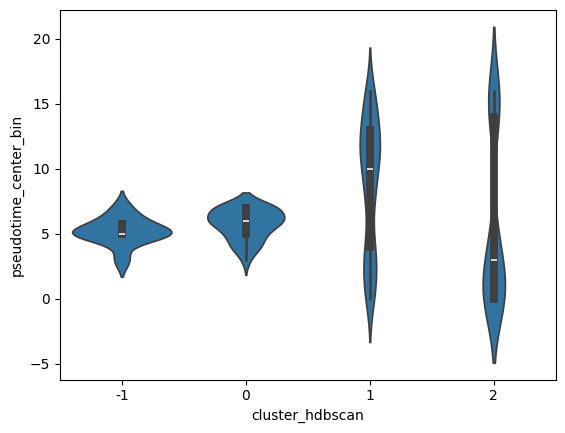

In [52]:
sns.violinplot(x='cluster_hdbscan', y='pseudotime_center_bin', data=SD_clean)
plt.show()

In [53]:
import os
import shutil
from tqdm import tqdm

def export_dapi_by_cluster(df, cluster_col, dapi_col, out_dir):
    """
    df          : pandas DataFrame
    cluster_col : column name containing cluster labels (e.g. 'cluster_hdbscan')
    dapi_col    : column name containing the DAPI file paths (e.g. 'path_dapi')
    out_dir     : output directory where cluster folders will be created
    """

    os.makedirs(out_dir, exist_ok=True)

    for cluster in sorted(df[cluster_col].unique()):
        cluster_path = os.path.join(out_dir, f"cluster_{cluster}")
        os.makedirs(cluster_path, exist_ok=True)

        sub_df = df[df[cluster_col] == cluster]

        print(f"Exporting {len(sub_df)} DAPI images for cluster {cluster}...")

        for _, row in tqdm(sub_df.iterrows(), total=len(sub_df)):
            src = row[dapi_col]
            
            if not os.path.exists(src):
                print(f"WARNING: File not found: {src}")
                continue

            # keep original filename
            filename = os.path.basename(src)
            dst = os.path.join(cluster_path, filename)

            shutil.copy(src, dst)

    print("Done.")

export_dapi_by_cluster(
    df=SD_clean,                # your dataframe
    cluster_col="cluster_hdbscan",   # or cluster_kmeans_no_outliers
    dapi_col="path_dapi",
    out_dir="sorted_dapi_images_UMAP+HDBSCAN_1462"     # will be created automatically
)

Exporting 10 DAPI images for cluster -1...


100%|██████████| 10/10 [00:00<00:00, 308.89it/s]


Exporting 29 DAPI images for cluster 0...


100%|██████████| 29/29 [00:00<00:00, 287.47it/s]


Exporting 248 DAPI images for cluster 1...


100%|██████████| 248/248 [00:00<00:00, 394.35it/s]


Exporting 127 DAPI images for cluster 2...


100%|██████████| 127/127 [00:00<00:00, 369.13it/s]

Done.


In [54]:

colums = ['ObjectNumber', 'Metadata_ObjNumber'] + feats

cluster_map = SD_clean[["Metadata_ObjNumber", "ObjectNumber", "cluster_hdbscan"]]

def add_cluster_to_cp(cp_df, cluster_map):
    return cp_df.merge(
        cluster_map,
        on=["Metadata_ObjNumber", "ObjectNumber"],
        how="inner"
    )  # avoid duplicate

df_identifyPrimaryObjects = add_cluster_to_cp(df_identifyPrimaryObjects, cluster_map)
df_Phalloidin_segmented = add_cluster_to_cp(df_Phalloidin_segmented, cluster_map)
df_YAP_segmented = add_cluster_to_cp(df_YAP_segmented, cluster_map)

df_identifyPrimaryObjects["cluster_hdbscan"]



0      1
1      1
2      2
3      2
4      1
      ..
409    1
410    0
411    2
412    1
413    2
Name: cluster_hdbscan, Length: 414, dtype: int64

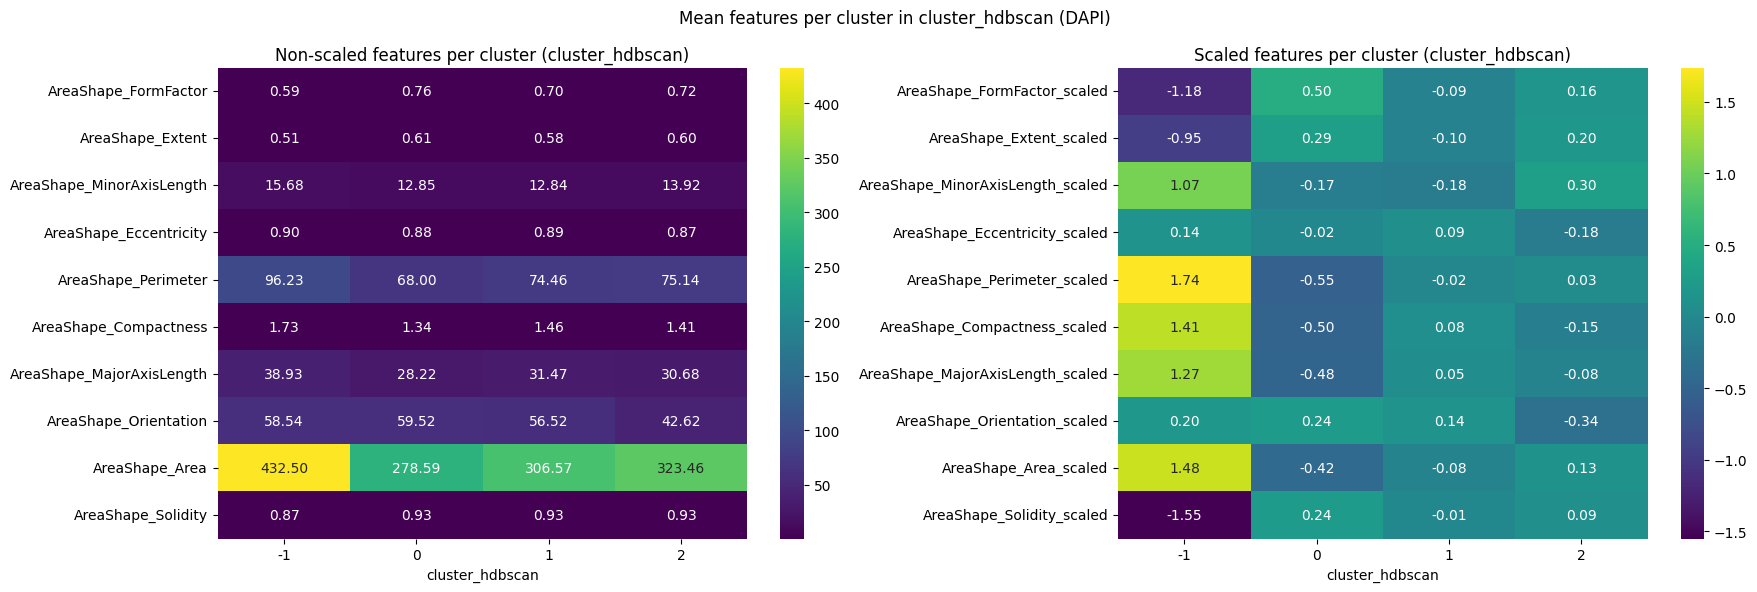

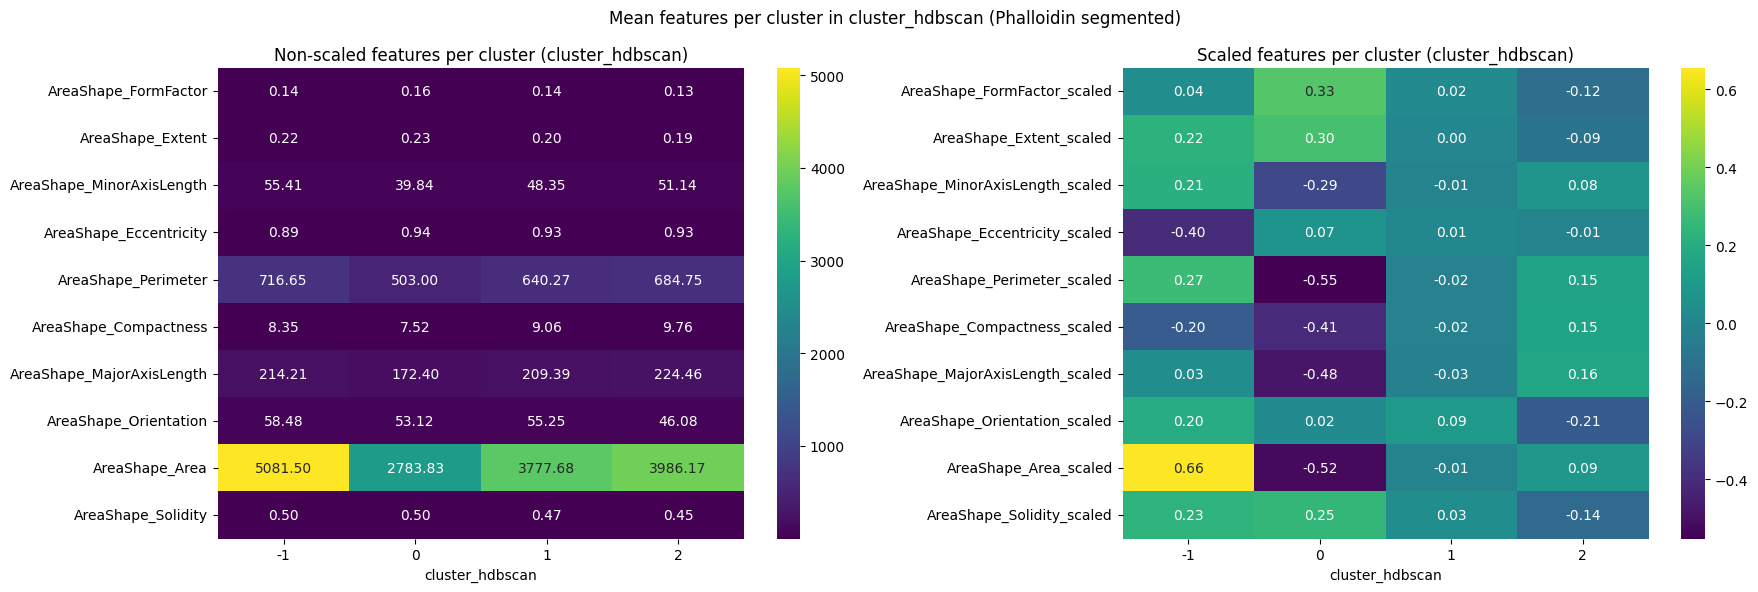

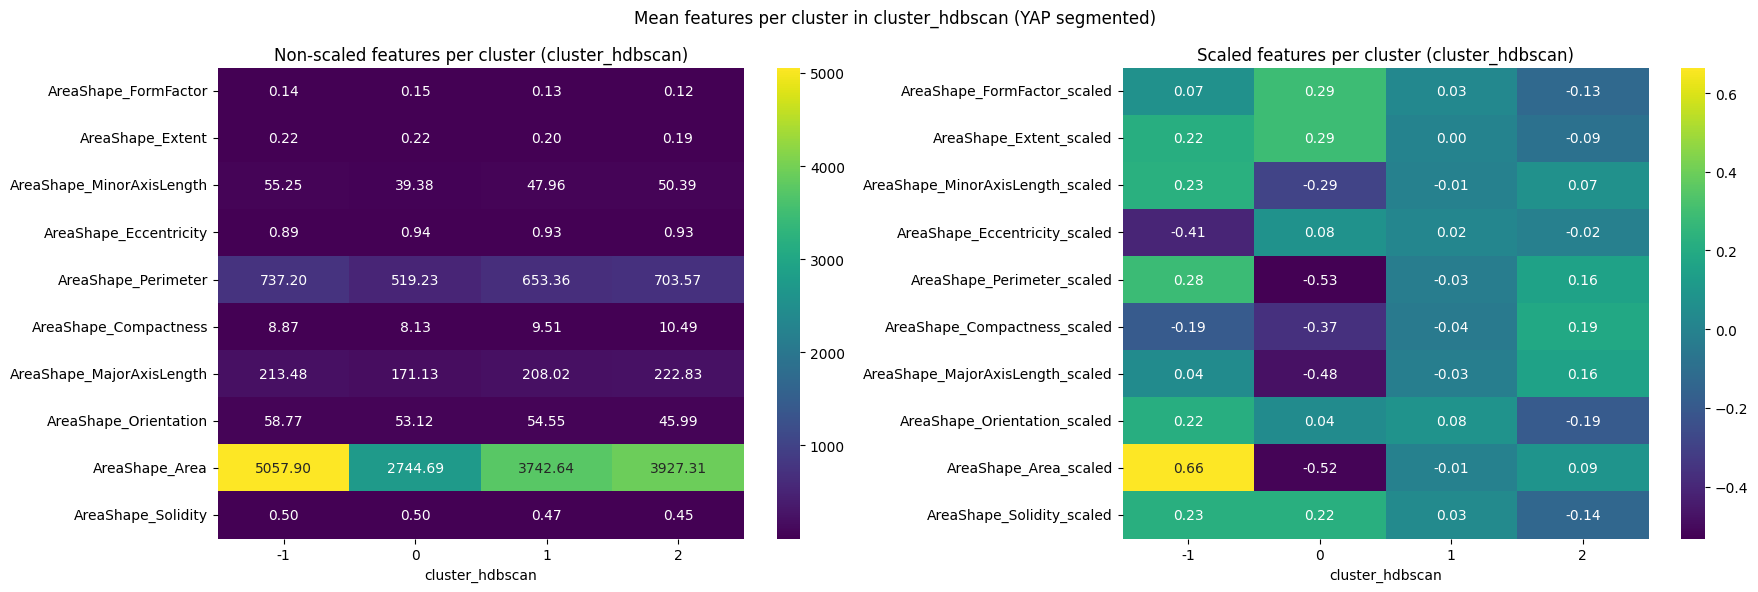

DAPI cluster counts:
cluster_hdbscan
 1    248
 2    127
 0     29
-1     10
Name: count, dtype: int64

Phalloidin segmented cluster counts:
cluster_hdbscan
 1    248
 2    127
 0     29
-1     10
Name: count, dtype: int64

YAP segmented cluster counts:
cluster_hdbscan
 1    248
 2    127
 0     29
-1     10
Name: count, dtype: int64


In [55]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df_identifyPrimaryObjects[feats])

feats_scaled = [f + "_scaled" for f in feats]   

df_identifyPrimaryObjects[feats_scaled] = scaled

plot_metadata_heatmap(
    df_identifyPrimaryObjects,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_hdbscan",
    title="DAPI"
)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_Phalloidin_segmented[feats])

df_Phalloidin_segmented[feats_scaled] = scaled

plot_metadata_heatmap(
    df_Phalloidin_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_hdbscan",
    title="Phalloidin segmented"
)

scaler = StandardScaler()
scaled = scaler.fit_transform(df_YAP_segmented[feats])

df_YAP_segmented[feats_scaled] = scaled

plot_metadata_heatmap(
    df_YAP_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_hdbscan",
    title="YAP segmented"
)

#counts per cluster
print("DAPI cluster counts:")
print(df_identifyPrimaryObjects["cluster_hdbscan"].value_counts())
print("\nPhalloidin segmented cluster counts:")
print(df_Phalloidin_segmented["cluster_hdbscan"].value_counts())
print("\nYAP segmented cluster counts:")
print(df_YAP_segmented["cluster_hdbscan"].value_counts())

In [56]:


def export_dapi_by_cluster(df, cluster_col, imgID_col, out_dir, Actin_dir, YAP_dir):
    """
    df          : pandas DataFrame
    cluster_col : column name containing cluster labels (e.g. 'cluster_hdbscan')
    imgID_col   : column name containing the image IDs (e.g. 'imgID')
    out_dir     : output directory where cluster folders will be created
    Actin_dir   : directory containing Actin images
    YAP_dir     : directory containing YAP images
    """

    os.makedirs(out_dir, exist_ok=True)

    for cluster in sorted(df[cluster_col].unique()):
        cluster_path = os.path.join(out_dir, f"cluster_{cluster}")
        os.makedirs(cluster_path, exist_ok=True)

        sub_df = df[df[cluster_col] == cluster]

        print(f"Exporting {len(sub_df)} DAPI images for cluster {cluster}...")

        for _, row in tqdm(sub_df.iterrows(), total=len(sub_df)):
            img_id = row[imgID_col]
            img_prefix = f"obj{img_id:04d}"

            # --- find matching Actin file ---
            actin_matches = [
                f for f in os.listdir(Actin_dir)
                if f.startswith(img_prefix)
            ]

            # --- find matching YAP file ---
            yap_matches = [
                f for f in os.listdir(YAP_dir)
                if f.startswith(img_prefix)
            ]

            # copy Actin files
            for f in actin_matches:
                src = os.path.join(Actin_dir, f)
                dst = os.path.join(cluster_path, f)
                shutil.copy(src, dst)

            # copy YAP files
            for f in yap_matches:
                src = os.path.join(YAP_dir, f)
                dst = os.path.join(cluster_path, f)
                shutil.copy(src, dst)


            shutil.copy(src, dst)

    print("Done.")


export_dapi_by_cluster(
    df=df_identifyPrimaryObjects,                # your dataframe
    cluster_col="cluster_hdbscan",   # or cluster_kmeans_no_outliers
    imgID_col="Metadata_ObjNumber",
    out_dir="sorted_YAP+ACTIN_by_cluster_UMAP+HDBSCAN_1462",     # will be created automatically
    Actin_dir="../1462_1/Actin_DAPI_overlays",
    YAP_dir="../1462_1/YAP_DAPI_overlays"
)



     

Exporting 10 DAPI images for cluster -1...


100%|██████████| 10/10 [00:00<00:00, 62.11it/s]


Exporting 29 DAPI images for cluster 0...


100%|██████████| 29/29 [00:00<00:00, 86.95it/s]


Exporting 248 DAPI images for cluster 1...


100%|██████████| 248/248 [00:02<00:00, 88.84it/s]


Exporting 127 DAPI images for cluster 2...


100%|██████████| 127/127 [00:01<00:00, 106.77it/s]

Done.


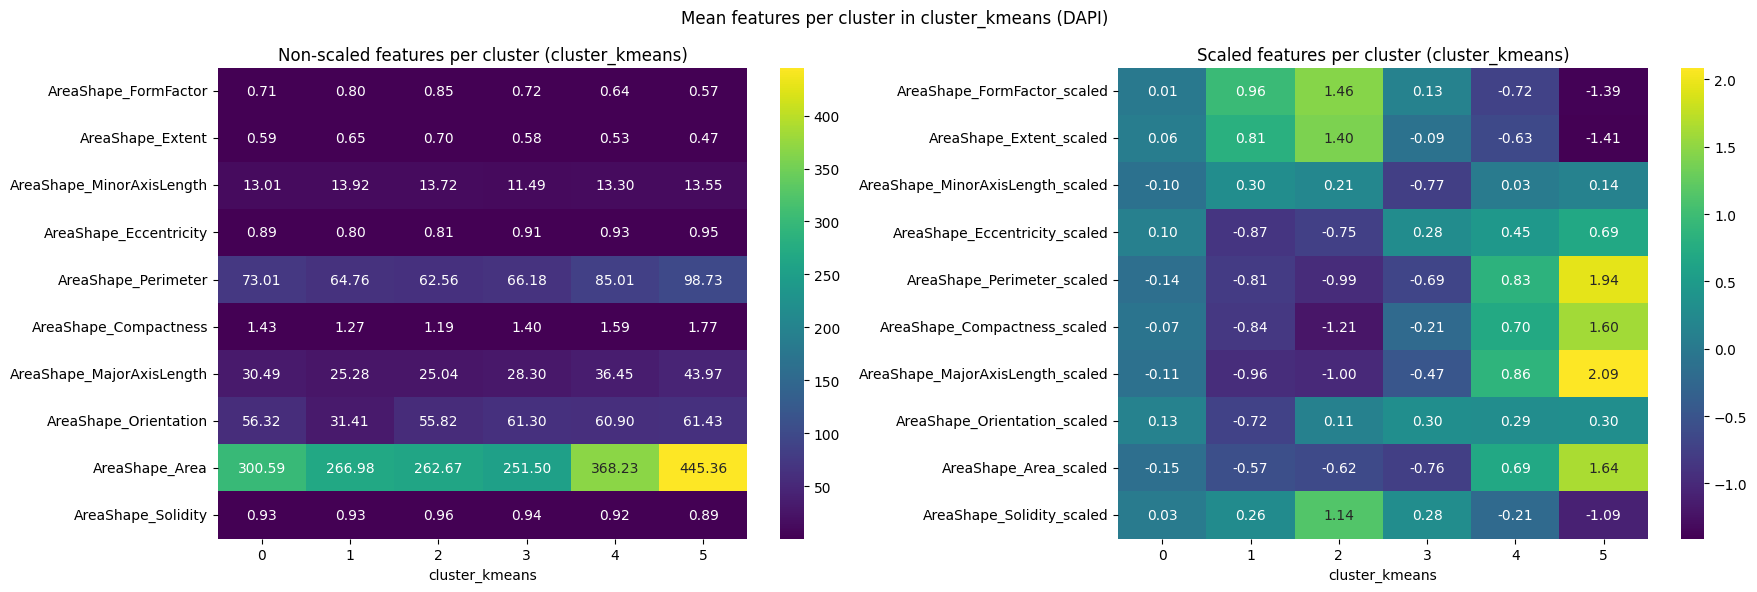

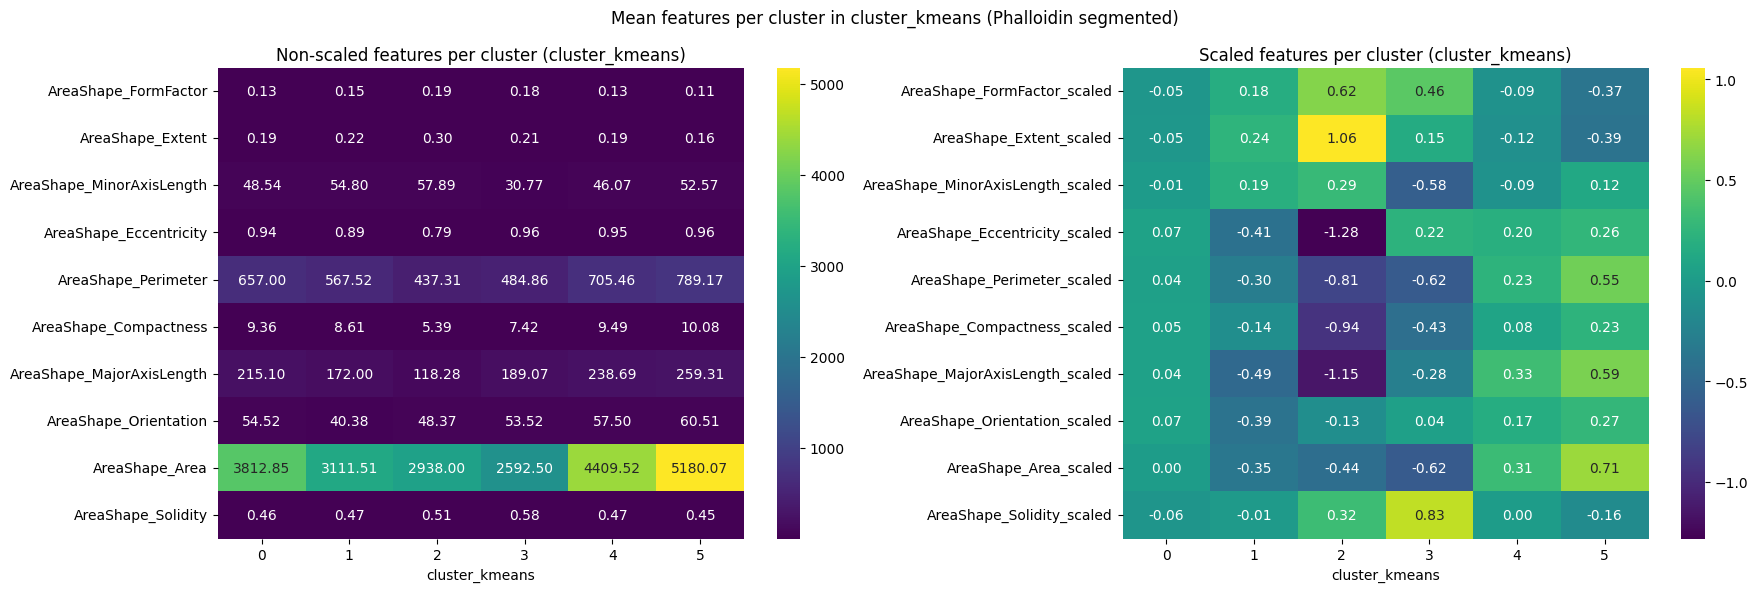

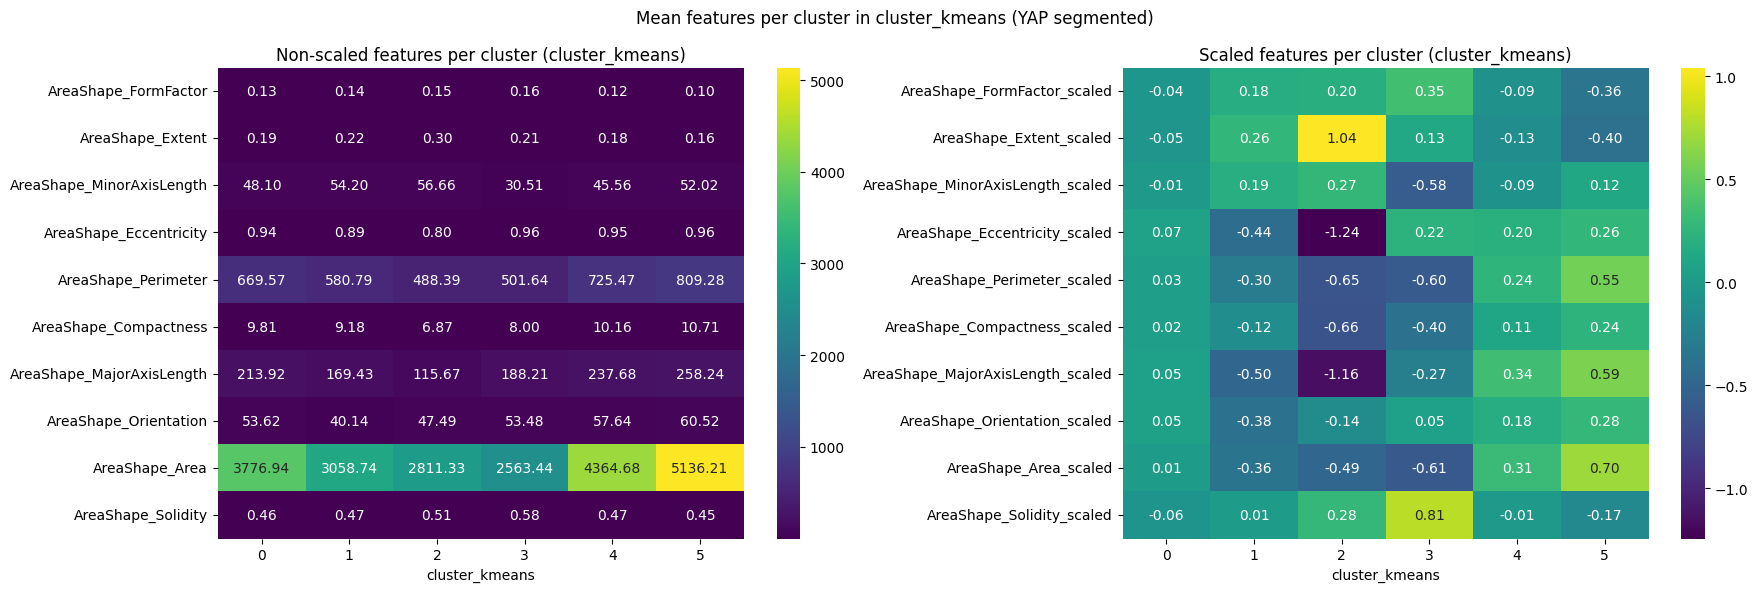

In [57]:
cluster_map_kmeans = SD_clean[["Metadata_ObjNumber", "ObjectNumber", "cluster_kmeans"]]

df_identifyPrimaryObjects = add_cluster_to_cp(df_identifyPrimaryObjects, cluster_map_kmeans)
df_Phalloidin_segmented = add_cluster_to_cp(df_Phalloidin_segmented, cluster_map_kmeans)
df_YAP_segmented = add_cluster_to_cp(df_YAP_segmented, cluster_map_kmeans)

plot_metadata_heatmap(
    df_identifyPrimaryObjects,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_kmeans",
    title="DAPI"
)

plot_metadata_heatmap(
    df_Phalloidin_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_kmeans",
    title="Phalloidin segmented"
)

plot_metadata_heatmap(
    df_YAP_segmented,
    feats_scaled,       # your list of scaled features
    feats,                # your list of non-scaled features
    "cluster_kmeans",
    title="YAP segmented"
)



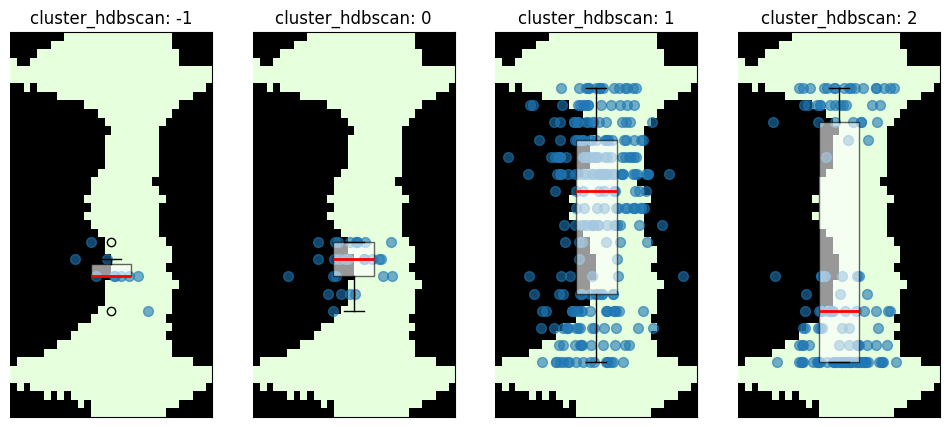

In [58]:
def plots_on_background(
    img_path,
    df,
    value_col,
    cluster_col,
    m=2,
    rotate=True,
    bw_method=0.3
):
    


    # --- load image ---
    img = plt.imread(img_path)

    img = np.rot90(img)

    if img.shape[2] == 3:
        alpha = np.ones((img.shape[0], img.shape[1], 1))
        img = np.concatenate([img, alpha], axis=2)
    
    mask = (img[:, :, :3] > 0.98).all(axis=2)

    img[mask] = img[mask] = [230/255, 255/255, 221/255, 1]    

    H, W = img.shape[:2]
    y_max = H / m

    buffer_px = H * (20 / 140)

    buffer_ratio = 20 / 140

    y_start = y_max * buffer_ratio
    y_end = y_max * (1 - buffer_ratio)

    plot_height = y_end - y_start

    clusters = sorted(df[cluster_col].dropna().unique())
    n_clusters = len(clusters)

    # create subplots (one per cluster)
    fig, axes = plt.subplots(
        1,
        n_clusters,
        figsize=(3 * n_clusters, 5),
        sharey=True
    )

    if n_clusters == 1:
        axes = [axes]

    for ax, cluster in zip(axes, clusters):

        # draw background image
        ax.imshow(
            img,
            extent=[0, W, 0, y_max],
            origin="upper",
            aspect="auto"
        )

        # extract cluster data
        data = (
            df.loc[df[cluster_col] == cluster, value_col]
            .dropna()
            .to_numpy()
        )

        y = y_start + data

        rng = np.random.default_rng(0)

        x = W/2 + rng.normal(0, W * 0.14, size=len(data))

        ax.scatter(
            x,
            y,
            s=50,
            alpha=0.6
        )

        
        ax.boxplot(
            y,
            positions=[W/2],
            widths=W * 0.2,
            vert=True,
            patch_artist=True,
            boxprops=dict(facecolor="white", alpha=0.6),
            medianprops=dict(color="red", linewidth=2),
            whiskerprops=dict(color="black"),
            capprops=dict(color="black")
        )

        ax.set_xlim(0, W)
        ax.set_ylim(0, y_max)
        ax.set_yticks([])
        ax.set_ylabel("")
        ax.spines["left"].set_visible(False)

        ax.set_title(f"{cluster_col}: {cluster}")
        ax.set_xticks([])

    plt.show()


plots_on_background(
    img_path="res\period_corridor_7_2026-03-20_14-34-04.png",
    df=SD_clean,
    value_col="pseudotime_center_bin",
    cluster_col="cluster_hdbscan"
)

In [59]:
for c in SD_clean["cluster_hdbscan"].unique():
    d = SD_clean.loc[SD_clean["cluster_hdbscan"] == c, "pseudotime_center_bin"]
    print(c, len(d), np.std(d))

1 248 5.017981130433854
2 127 6.478367690899913
-1 10 0.9797958971132713
0 29 1.1342678760964502


In [60]:
SD_clean.to_csv("datasets/combined_clustered_data 1462.csv", index=False)

Original feature shape: (414, 18)
PCA shape: (414, 8)
Explained variance ratio sum: 0.9625078183581212


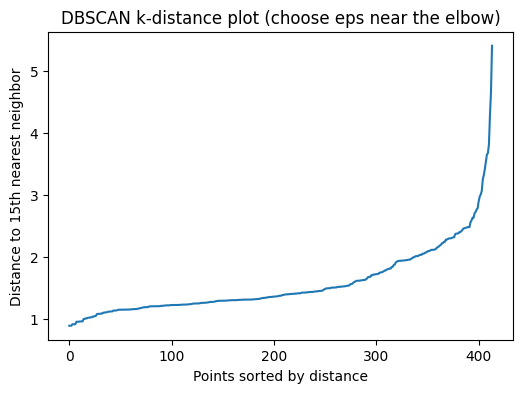

Initial eps guess: 2.298
Cluster sizes: {np.int64(-1): np.int64(8), np.int64(0): np.int64(406)}
Silhouette not computed: fewer than 2 non-noise clusters.


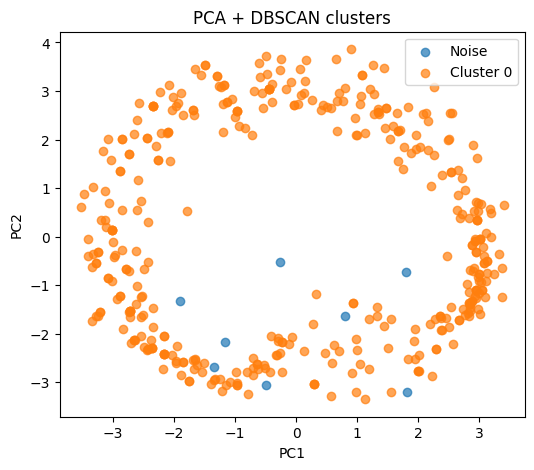

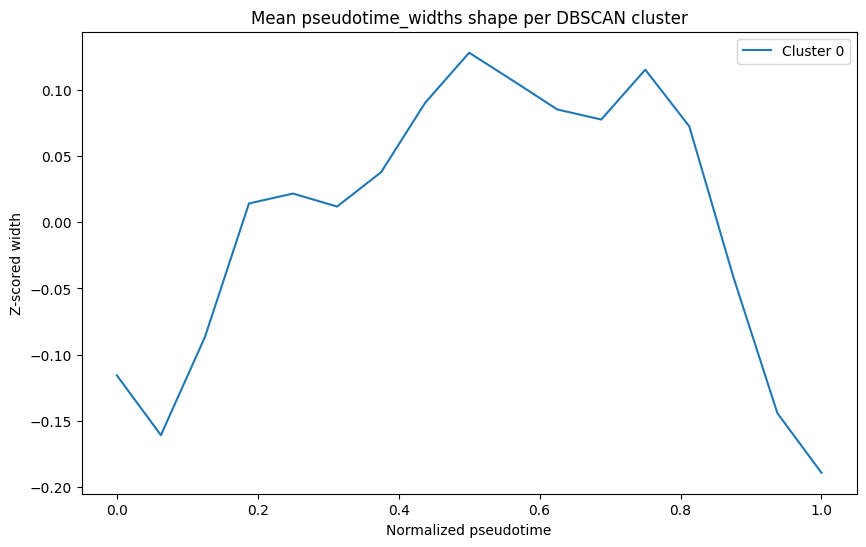

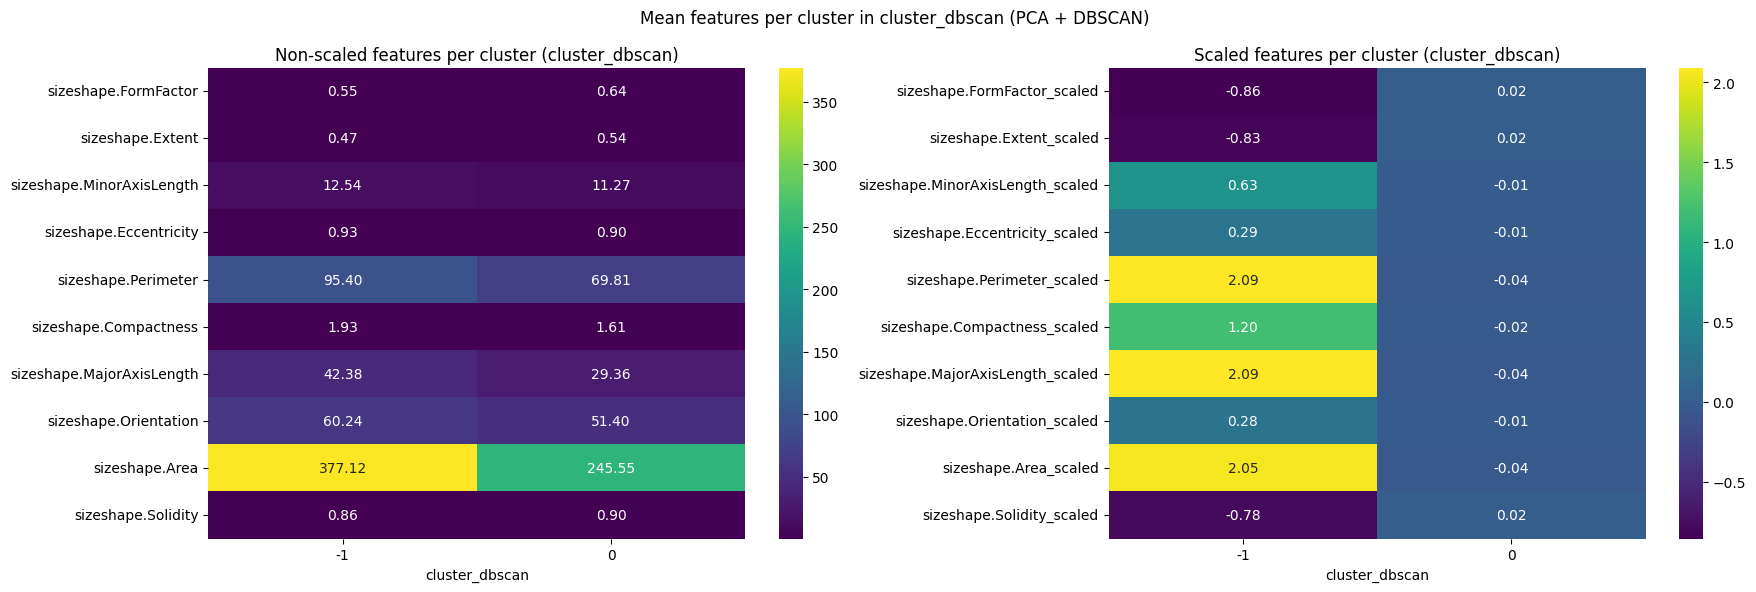

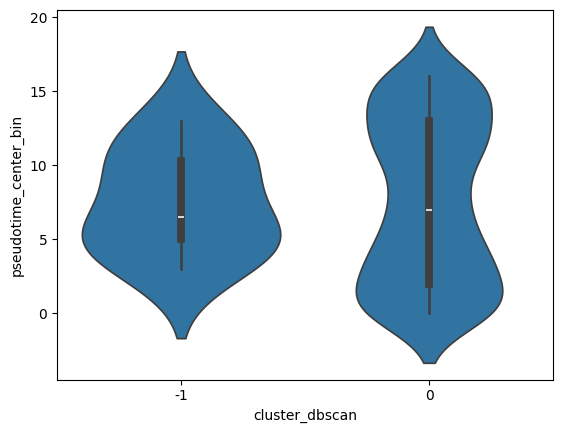

In [61]:
#NK plots PCA + HDBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# PCA + DBSCAN for variable-length pseudotime_widths
# ============================================================

# Use the already filtered dataframe
# (you already filtered SD_clean for len >= n earlier)
X_series = SD_clean["pseudotime_widths"].to_list()

def zscore_ts(ts):
    ts = np.asarray(ts, dtype=float)
    s = ts.std()
    if s == 0:
        return np.zeros_like(ts)
    return (ts - ts.mean()) / s

def resample_ts(ts, target_len):
    ts = zscore_ts(ts)
    x_old = np.linspace(0, 1, len(ts))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, ts)

# --- 1) Convert variable-length trajectories to fixed-length vectors ---
target_len = int(np.median([len(ts) for ts in X_series]))  # deterministic choice
X_shape = np.vstack([resample_ts(ts, target_len) for ts in X_series])

# Optional: keep original trajectory length as extra information
orig_len = np.array([len(ts) for ts in X_series], dtype=float).reshape(-1, 1)
orig_len_scaled = StandardScaler().fit_transform(orig_len)

# Final feature matrix for PCA
X_features = np.hstack([X_shape, orig_len_scaled])

# --- 2) Scale ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# --- 3) PCA for clustering (deterministic) ---
pca = PCA(n_components=0.95, svd_solver="full")
X_pca = pca.fit_transform(X_scaled)

print("Original feature shape:", X_features.shape)
print("PCA shape:", X_pca.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

# Separate 2D PCA only for plotting
pca_plot = PCA(n_components=2, svd_solver="full")
X_plot = pca_plot.fit_transform(X_scaled)

# --- 4) k-distance plot to choose eps ---
min_samples = 15

nbrs = NearestNeighbors(n_neighbors=min_samples)
nbrs.fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)

kdist = np.sort(distances[:, -1])

plt.figure(figsize=(6, 4))
plt.plot(kdist)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("DBSCAN k-distance plot (choose eps near the elbow)")
plt.show()

# Starting guess for eps
eps_guess = np.percentile(distances[:, -1], 90)
print(f"Initial eps guess: {eps_guess:.3f}")

# --- 5) DBSCAN ---
dbscan = DBSCAN(
    eps=eps_guess,      # tune this after looking at the elbow plot
    min_samples=min_samples,
    metric="euclidean"
)

labels_dbscan = dbscan.fit_predict(X_pca)

unique, counts = np.unique(labels_dbscan, return_counts=True)
print("Cluster sizes:", dict(zip(unique, counts)))

# Optional silhouette (ignore noise)
mask = labels_dbscan != -1
if len(np.unique(labels_dbscan[mask])) >= 2:
    sil = silhouette_score(X_pca[mask], labels_dbscan[mask])
    print("Silhouette (non-noise only):", sil)
else:
    print("Silhouette not computed: fewer than 2 non-noise clusters.")

# --- 6) Plot clusters in 2D PCA space ---
plt.figure(figsize=(6, 5))
for c in np.unique(labels_dbscan):
    idx = labels_dbscan == c
    label = "Noise" if c == -1 else f"Cluster {c}"
    plt.scatter(X_plot[idx, 0], X_plot[idx, 1], label=label, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA + DBSCAN clusters")
plt.legend()
plt.show()

# --- 7) Store labels back in your dataframe ---
SD_clean["cluster_dbscan"] = labels_dbscan

# --- 8) Plot mean resampled shape per cluster ---
x_common = np.linspace(0, 1, target_len)

plt.figure(figsize=(10, 6))
for lab in np.unique(labels_dbscan):
    if lab == -1:
        continue
    cluster_mean = X_shape[labels_dbscan == lab].mean(axis=0)
    plt.plot(x_common, cluster_mean, label=f"Cluster {lab}")

plt.xlabel("Normalized pseudotime")
plt.ylabel("Z-scored width")
plt.title("Mean pseudotime_widths shape per DBSCAN cluster")
plt.legend()
plt.show()

# --- 9) Reuse your downstream plots ---
plot_metadata_heatmap(
    SD_clean,
    feats_CPmeasure_scaled,
    feats_CPmeasure,
    "cluster_dbscan",
    title="PCA + DBSCAN"
)

sns.violinplot(x="cluster_dbscan", y="pseudotime_center_bin", data=SD_clean)
plt.show()

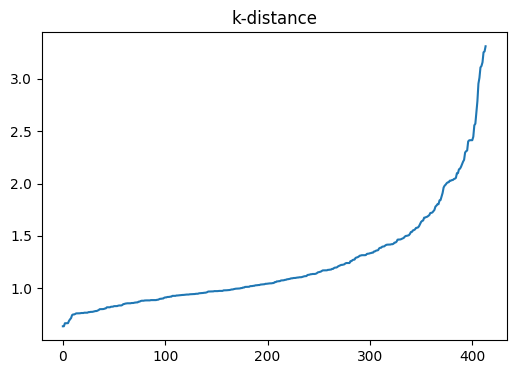

eps = 1.2 {np.int64(-1): np.int64(70), np.int64(0): np.int64(228), np.int64(1): np.int64(88), np.int64(2): np.int64(28)}
eps = 1.4 {np.int64(-1): np.int64(41), np.int64(0): np.int64(359), np.int64(1): np.int64(14)}
eps = 1.6 {np.int64(-1): np.int64(29), np.int64(0): np.int64(385)}
eps = 1.8 {np.int64(-1): np.int64(20), np.int64(0): np.int64(394)}
eps = 2.0 {np.int64(-1): np.int64(8), np.int64(0): np.int64(406)}


In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

X_series = SD_clean["pseudotime_widths"].to_list()

def resample_ts_raw(ts, target_len):
    ts = np.asarray(ts, dtype=float)
    x_old = np.linspace(0, 1, len(ts))
    x_new = np.linspace(0, 1, target_len)
    return np.interp(x_new, x_old, ts)

target_len = int(np.median([len(ts) for ts in X_series]))
X_shape = np.vstack([resample_ts_raw(ts, target_len) for ts in X_series])

# optional: add original length
orig_len = np.array([len(ts) for ts in X_series], dtype=float).reshape(-1, 1)

X_features = np.hstack([X_shape, orig_len])

# global scaling, not per-trajectory z-scoring
X_scaled = StandardScaler().fit_transform(X_features)

# fewer PCs for clustering
pca = PCA(n_components=5, svd_solver="full")
X_pca = pca.fit_transform(X_scaled)

# k-distance
min_samples = 15
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
kdist = np.sort(distances[:, -1])

plt.figure(figsize=(6,4))
plt.plot(kdist)
plt.title("k-distance")
plt.show()

# try a range manually
for eps in [1.2, 1.4, 1.6, 1.8, 2.0]:
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_pca)
    unique, counts = np.unique(labels, return_counts=True)
    print("eps =", eps, dict(zip(unique, counts)))

In [65]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

for k in [2, 3, 4,5 ,6,7,8,9,10]:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    unique, counts = np.unique(labels, return_counts=True)
    print(f"k={k}, silhouette={sil:.3f}, sizes={dict(zip(unique, counts))}")

k=2, silhouette=0.269, sizes={np.int64(0): np.int64(263), np.int64(1): np.int64(151)}
k=3, silhouette=0.353, sizes={np.int64(0): np.int64(163), np.int64(1): np.int64(151), np.int64(2): np.int64(100)}
k=4, silhouette=0.388, sizes={np.int64(0): np.int64(151), np.int64(1): np.int64(79), np.int64(2): np.int64(100), np.int64(3): np.int64(84)}
k=5, silhouette=0.407, sizes={np.int64(0): np.int64(79), np.int64(1): np.int64(93), np.int64(2): np.int64(100), np.int64(3): np.int64(84), np.int64(4): np.int64(58)}
k=6, silhouette=0.414, sizes={np.int64(0): np.int64(100), np.int64(1): np.int64(93), np.int64(2): np.int64(46), np.int64(3): np.int64(84), np.int64(4): np.int64(58), np.int64(5): np.int64(33)}
k=7, silhouette=0.385, sizes={np.int64(0): np.int64(93), np.int64(1): np.int64(84), np.int64(2): np.int64(46), np.int64(3): np.int64(71), np.int64(4): np.int64(58), np.int64(5): np.int64(33), np.int64(6): np.int64(29)}
k=8, silhouette=0.387, sizes={np.int64(0): np.int64(84), np.int64(1): np.int64(71)

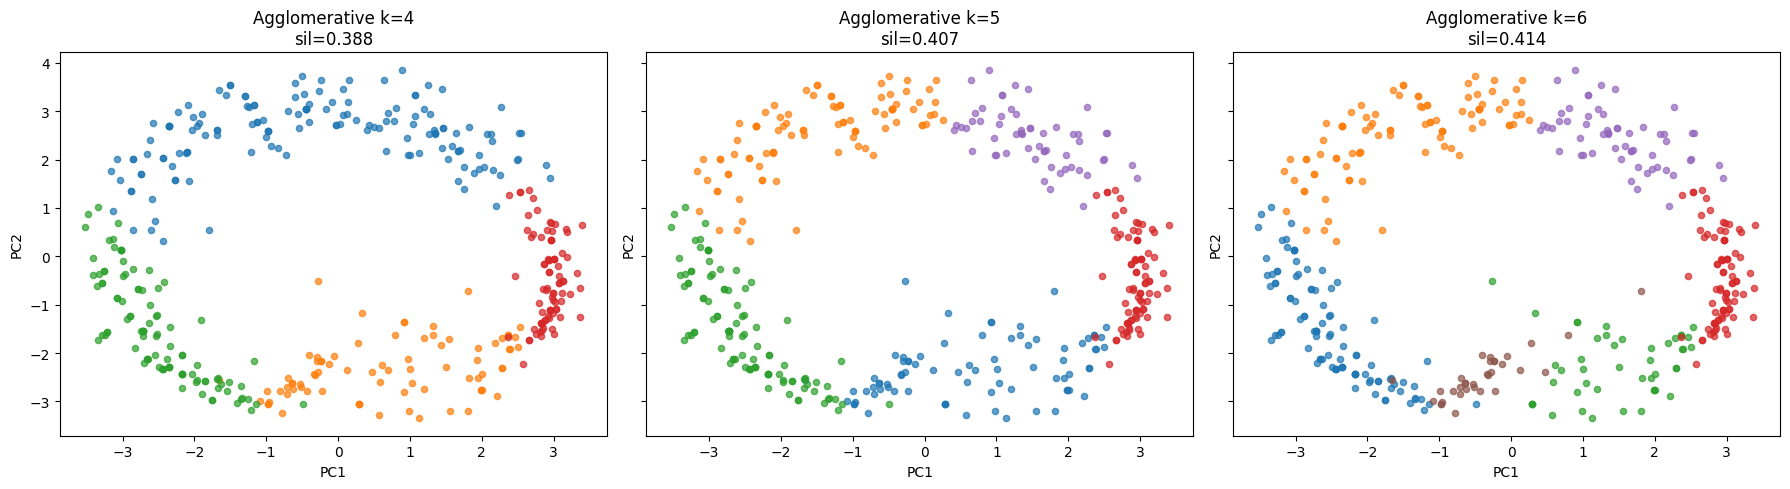

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, k in zip(axes, ks):
    labels = results[k]["labels"]

    for c in np.unique(labels):
        idx = labels == c
        ax.scatter(X_plot[idx, 0], X_plot[idx, 1], s=20, alpha=0.7, label=f"C{c}")

    ax.set_title(f"Agglomerative k={k}\nsil={results[k]['silhouette']:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, k in zip(axes, ks):
    labels = results[k]["labels"]

    for lab in np.unique(labels):
        cluster_mean = X_shape[labels == lab].mean(axis=0)
        ax.plot(x_common, cluster_mean, label=f"Cluster {lab}")

    ax.set_title(f"Mean pseudotime_widths\nk={k}")
    ax.set_xlabel("Normalized pseudotime")
    ax.set_ylabel("Width")
    ax.legend()

plt.tight_layout()
plt.show()